In [3]:
#Packages to use pytorch
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F
import torchvision.transforms as transforms

# Que es la Convolución
Es una operación matemática que combina dos señales del mismo número de dimensiones. En el contexto de imagenes, combina una imagen/canal con un kernel:

![convolutions](https://consuledge.com.au/wp-content/uploads/2024/12/Convolution-operation-diagram.png)
$$
x(t)*h(t) = y(t)
$$

In [4]:
def convolution(image, kernel):
    #Zero padding
    shift_row = kernel.shape[0]//2
    shift_col = kernel.shape[1]//2

    new_image = np.zeros((image.shape[0] + 2*shift_row, image.shape[1] + 2*shift_col),
                         np.float32)
    new_image[shift_row:image.shape[0]+shift_row,shift_col:image.shape[1]+shift_col] = image

    #Imagen resultante
    new_image2 = np.zeros((new_image.shape[0], new_image.shape[1]), np.float32)

    #Perform filtering
    for i in range(shift_row, image.shape[0]+shift_row):
        for j in range(shift_col, image.shape[1]+shift_col):
            aux = new_image[i-shift_row:i+shift_row+1, j-shift_col:j+shift_col+1]
            new_image2[i,j] = np.sum(aux*kernel)

    return new_image2[shift_row:image.shape[0]+shift_row,shift_col:image.shape[1]+shift_col]

- Explique que parte de este código hace el cálculo de la multiplicación.
- Defina lo que es el padding.


[[0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]]


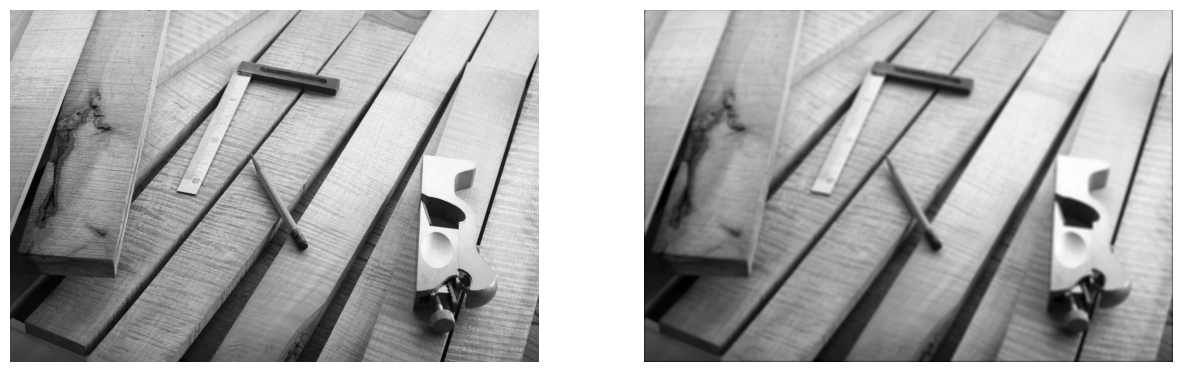

In [6]:
im = cv2.imread('images/wood.jpg', 0)
sizeKernel = 7
kernel = (1/(sizeKernel**2))*np.ones((sizeKernel,sizeKernel))
print(kernel)
im2 = convolution(im, kernel)

plt.figure(figsize=(15,15))
plt.subplot(1,2,1), plt.imshow(im, cmap='gray'), plt.axis(False)
plt.subplot(1,2,2), plt.imshow(im2, cmap='gray'), plt.axis(False)
plt.show()


[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]


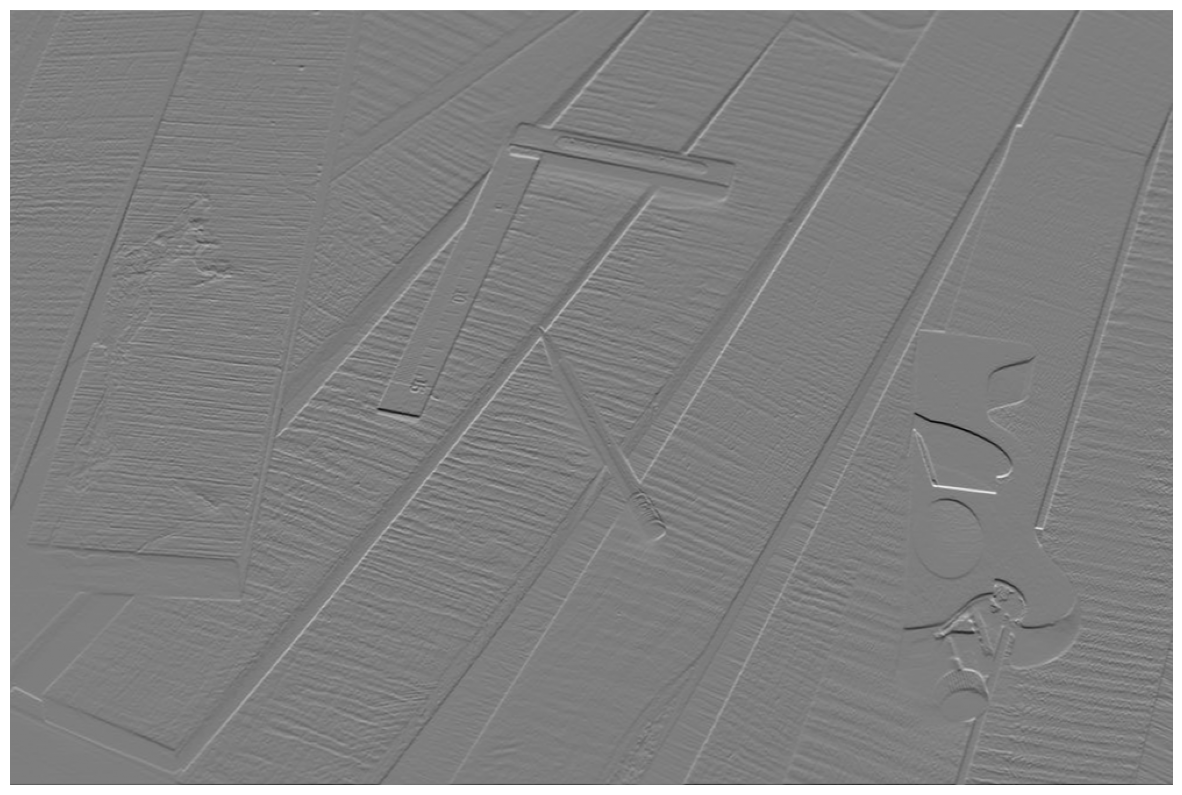

In [7]:
kernel = np.array([[-1, -2, -1],[0,0,0],[1, 2, 1]], int)
print(kernel)
im2 = convolution(im, kernel)

plt.figure(figsize=(15,15))
plt.imshow(im2, cmap='gray'), plt.axis(False)
plt.show()

[[-4  0  0]
 [ 0  0  0]
 [ 0  0  4]]


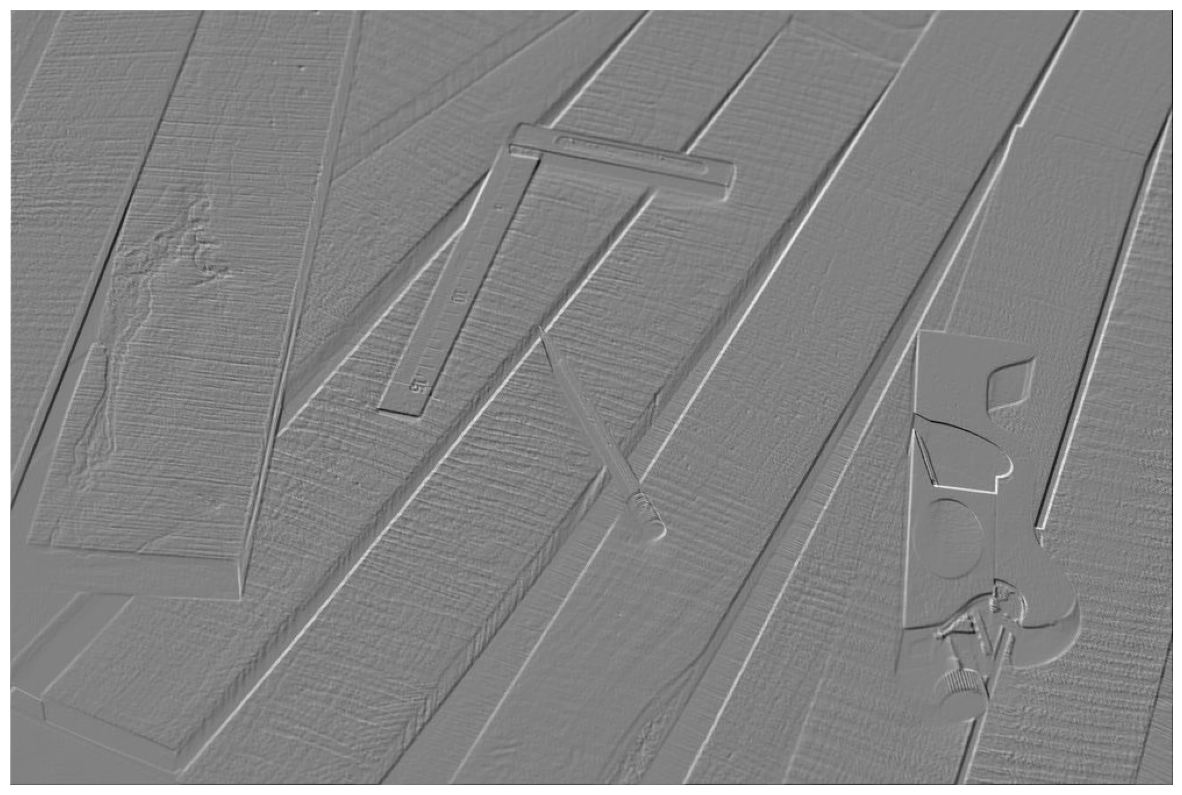

In [13]:
kernel = np.array([[-4, 0, 0],[0,0,0],[0, 0, 4]], int)
print(kernel)
im2 = convolution(im, kernel)

plt.figure(figsize=(15,15))
plt.imshow(im2, cmap='gray'), plt.axis(False)
plt.show()

In [14]:
print("im2 =",np.max(im2))
print("im2 =",np.min(im2))

im2 = 940.0
im2 = -968.0


- Qué valores tienen las imágenes generadas?
- Pruebe algún otro patrón.

# Manejo de datos
Ahora vamos a jugar con la base de datos MNIST usada para clasificacion de numeros.


![mnist_image](https://imgs.search.brave.com/zu928HMyiVgu2oEOXCftse5OywqblAwfXQZ7Zbs9S4A/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9tZWRp/YS5nZWVrc2Zvcmdl/ZWtzLm9yZy93cC1j/b250ZW50L3VwbG9h/ZHMvMjAyNjAxMDIx/NjA3MzgzNzI1MzEv/bW5pc3QucG5n)


In [15]:
from torch.utils.data import Subset
# 1. Define transformations (convert to tensor and normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2. Load the dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

indices = torch.randperm(len(train_dataset))[:5000] # Select first 1000 random samples
train_dataset = Subset(train_dataset, indices)

# 3. Create DataLoaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

# Redes convolucionales



In [38]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
    self.fc1 = nn.Linear(5*5*64, 256)
    self.fc2 = nn.Linear(256,10)

  def forward(self, x):
    # x es 28 x 28
    x = F.relu(F.max_pool2d(self.conv1(x), 2)) #[64, 1, 28,28] -> [64,16,14,14]
    x = F.relu(F.max_pool2d(self.conv2(x), 2))
    x = F.relu(self.conv3(x))
    x = x.view(-1, 5*5*64)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return F.log_softmax(x,dim=1)

network = Net()
tensor_example = torch.rand([64,1,28,28])
result = network(tensor_example)
type_device = 'cuda' # cuda
device = torch.device(type_device)
network = network.to(device)

In [39]:
lr = 0.001
momentum = 0.9
optimizer = optim.SGD(network.parameters(), lr=lr, momentum=momentum,)
# Train the model
num_epochs = 10
log_interval = 10
accuracy_epochs = []

train_losses = []
train_counter = []
test_losses = []


#Function to train one epoch
def train(network, optimizer,  epoch, train_losses):
    network.train() #Modo
    train_loss = 0
    for batchId, (data, target) in enumerate(train_loader): #Iterate over batches
        data = data.to(device)
        target = target.to(device)

        #Feedforward pass
        optimizer.zero_grad()
        output = network(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses += [train_loss/len(indices)]


#Testing
def test(network, test_losses):
    network.eval() #Test mode
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            output = network(data)
            test_loss += F.nll_loss(output, target, size_average=False).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
    length = len(test_loader.dataset)
    test_loss /= length
    test_losses.append(test_loss)


for epoch in tqdm(range(num_epochs)):
    train(network, optimizer, epoch,train_losses)
    test(network,test_losses)
    train_counter += [epoch]
    if epoch % log_interval==0:
        print('Train epoch: {}  Loss train: {:.6f} loss test  {:.6f}'.format(epoch,  test_losses[-1], test_losses[-1]))
        torch.save(network.state_dict(),'model_{:d}.pth'.format(epoch))
        torch.save(optimizer.state_dict(), 'optimizer.pth')



  0%|                                                    | 0/10 [00:00<?, ?it/s]

180.9576919078827


 10%|████▍                                       | 1/10 [00:01<00:17,  1.91s/it]

Train epoch: 0  Loss train: 2.272700 loss test  2.272700
177.1521737575531


 20%|████████▊                                   | 2/10 [00:05<00:25,  3.17s/it]

...

 80%|███████████████████████████████████▏        | 8/10 [00:20<00:04,  2.29s/it]

26.160684317350388


 90%|███████████████████████████████████████▌    | 9/10 [00:21<00:02,  2.00s/it]

23.837298206984997


100%|███████████████████████████████████████████| 10/10 [00:22<00:00,  2.29s/it]


- Porque se define una capa lineal en la red? ¿Qué significa esta línea?
```
  x = x.view(-1, 5*5*64)
```
- ¿Cuántas épocas se requirieron para entrenar el modelo a un nivel razonable?
- Modifique la función para calcular accuracy en cada iteración.


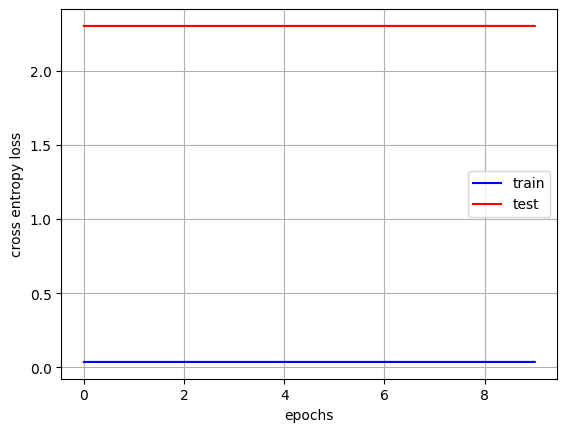

In [35]:
plt.figure()
plt.plot(train_counter, train_losses, color='blue',label='train')
plt.plot(train_counter, test_losses, color='red',label='test')
plt.legend()
plt.ylabel("cross entropy loss")
plt.xlabel("epochs")
plt.grid()
plt.show()


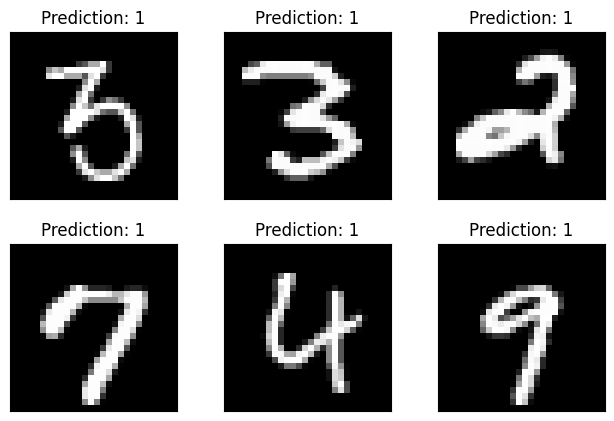

In [37]:
(exampleData, exampleTargets) = next(iter(train_loader)) #Next batch
with torch.no_grad():
  output = network(exampleData.to(device))

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(exampleData[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()


In [36]:
network = Net().to(device)

with torch.no_grad():
    for param in network.parameters():
        param.data = nn.parameter.Parameter(torch.zeros_like(param))

# Sanity check-
print(network.state_dict()['fc1.weight'])


tensor([[-1.5623e+14, -3.0075e+14, -4.0102e+14,  ..., -4.5932e+14,
         -3.7341e+14, -2.0196e+14],
        [-1.5623e+14, -3.0075e+14, -4.0102e+14,  ..., -4.5932e+14,
         -3.7341e+14, -2.0196e+14],
        [-1.5623e+14, -3.0075e+14, -4.0102e+14,  ..., -4.5932e+14,
         -3.7341e+14, -2.0196e+14],
        ...,
        [-1.5623e+14, -3.0075e+14, -4.0102e+14,  ..., -4.5932e+14,
         -3.7341e+14, -2.0196e+14],
        [-1.5623e+14, -3.0075e+14, -4.0102e+14,  ..., -4.5932e+14,
         -3.7341e+14, -2.0196e+14],
        [-1.5623e+14, -3.0075e+14, -4.0102e+14,  ..., -4.5932e+14,
         -3.7341e+14, -2.0196e+14]], device='cuda:0')


# Inicializacion de parametros
1. Realice un entrenamiento con pesos iniciales iguales a algun valor identico.

In [33]:
train_losses = []
train_counter = []
test_losses = []


for epoch in tqdm(range(num_epochs)):
    train(network, optimizer, epoch,train_losses)
    test(network,test_losses)
    train_counter += [epoch]
    if epoch % log_interval:
        print('Train epoch: {}  Loss train: {:.6f} loss test  {:.6f}'.format(epoch,  train_losses[-1], test_losses[-1]))
        torch.save(network.state_dict(),'model.pth')
        torch.save(optimizer.state_dict(), 'optimizer.pth')


  0%|                                                    | 0/10 [00:00<?, ?it/s]

181.69639778137207


 10%|████▍                                       | 1/10 [00:00<00:08,  1.12it/s]

181.71307730674744


 20%|████████▊                                   | 2/10 [00:01<00:07,  1.13it/s]

...

Train epoch: 7  Loss train: 0.036339 loss test  2.301333
181.6706190109253


 90%|███████████████████████████████████████▌    | 9/10 [00:07<00:00,  1.26it/s]

Train epoch: 8  Loss train: 0.036334 loss test  2.301361
181.6603865623474


100%|███████████████████████████████████████████| 10/10 [00:08<00:00,  1.24it/s]

Train epoch: 9  Loss train: 0.036332 loss test  2.301356


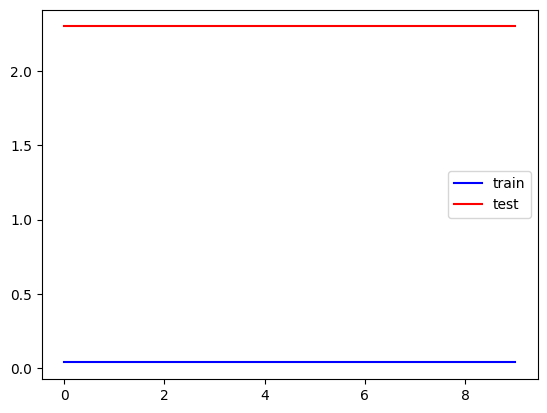

In [30]:
plt.figure()
plt.plot(train_counter, train_losses, color='blue',label='train')
plt.plot(train_counter, test_losses, color='red',label='test')
plt.legend()
plt.show()


# Grafos virtuales

In [40]:
from torchviz import make_dot

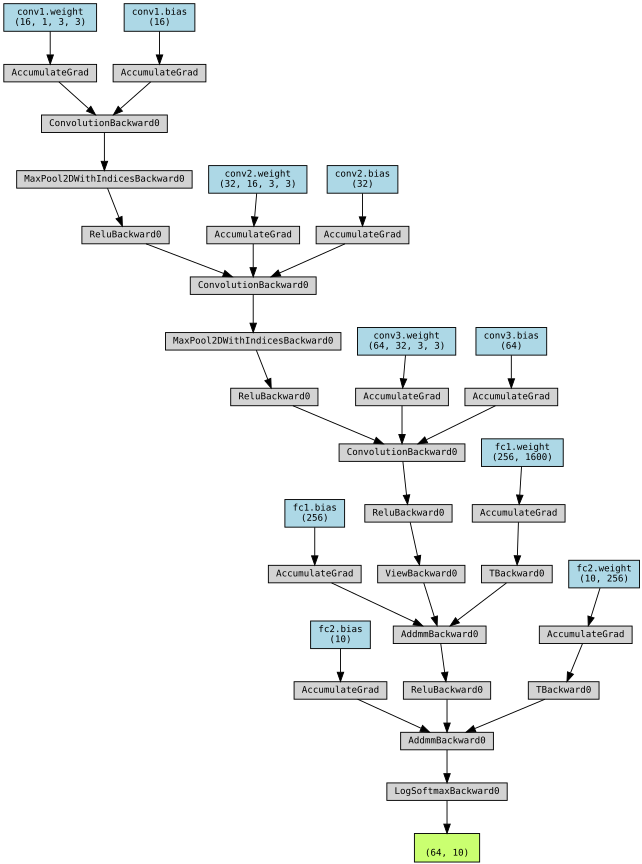

In [41]:
(exampleData, exampleTargets) = next(iter(train_loader)) #Next batch
# with torch.no_grad():
output = network(exampleData.to(device))

make_dot(output, params=dict(network.named_parameters()))

- Donde esta definida la operacion de convolucion 1?
- Donde esta la primera capa fully connected? 